# Deconvolved Spatial Transcriptomics Data Analysis

In [4]:
# Import 
library(Seurat)
library(grid)
library(ggplot2)
library(viridis)
library(dplyr)
library(patchwork)
set.seed(1)

library(future)
plan("multicore", workers = 10) 
options(future.globals.maxSize = 16000 * 1024^2) 
future.seed=TRUE

data_dir <- "./slice_Tongue Cancer/deconvolved"

print("Loading 10X Spatial data...")
seurat_obj <- Load10X_Spatial(
  data.dir = data_dir,
)

seurat_obj@project.name <- "Breast Cancer"

seurat_obj

[1] "Loading 10X Spatial data..."


An object of class Seurat 
17896 features across 11272 samples within 1 assay 
Active assay: Spatial (17896 features, 0 variable features)
 1 layer present: counts
 1 spatial field of view present: slice1

[1] "Running QC..."


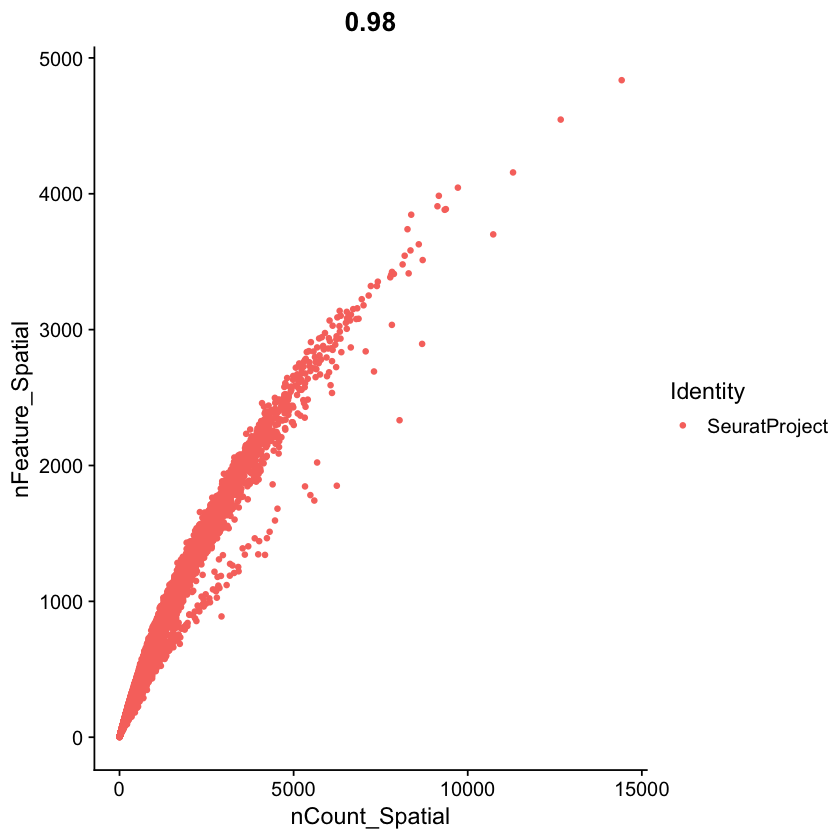

In [5]:
# Quality Control 
print("Running QC...")

FeatureScatter(seurat_obj, feature1 = "nCount_Spatial", feature2 = "nFeature_Spatial")

Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Seurat objects”


An object of class Seurat 
17896 features across 11261 samples within 1 assay 
Active assay: Spatial (17896 features, 0 variable features)
 1 layer present: counts
 1 spatial field of view present: slice1

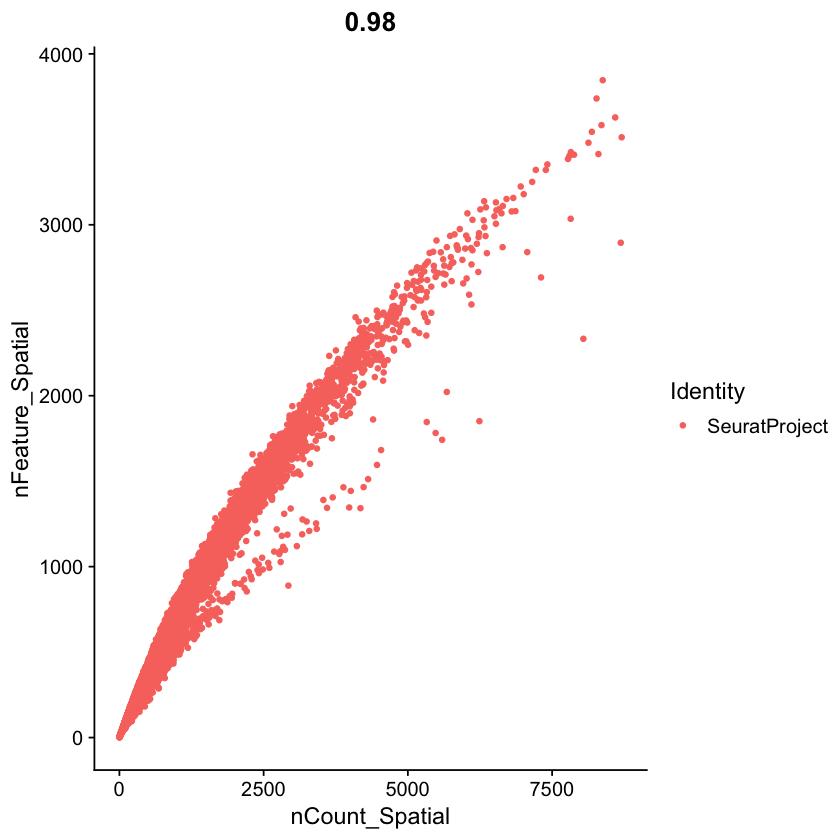

In [6]:
seurat_obj <- subset(seurat_obj, subset = nFeature_Spatial > 0 & nCount_Spatial < 9000)

FeatureScatter(seurat_obj, feature1 = "nCount_Spatial", feature2 = "nFeature_Spatial")

seurat_obj

[1] "Normalizing and Scaling..."


Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix



[1] "Running PCA..."


PC_ 1 
Positive:  CKM, DES, TNNT3, TTN, TCAP, TNNC2, MYH1, ACTC1, PDLIM3, KLHL41 
	   SYNPO2, CMYA5, MUSTN1, TPM2, MYBPC1, THBS4, MYH2, MYL1, ACTN2, BIN1 
	   EEF1A2, CSRP3, SLN, MYLPF, CRYAB, ENO3, TRDN, STAC3, FLNC, SPTB 
Negative:  KRT14, KRT5, MMP1, COL17A1, S100A2, PERP, SLC2A1, LAMC2, SDC4, LAMB3 
	   ITGA3, DSP, FXYD3, COL7A1, CD44, ITGB4, TXN, KRT16, LAMA3, MMP13 
	   SDC1, PPP1R14C, ISG15, TP63, F3, DDR1, RHOD, SPINT2, BCAM, CAV2 
PC_ 2 
Positive:  LAMC2, TXN, SLC3A2, ITGB4, ITGA3, PRSS23, MMP13, JPT1, TP63, LAMA3 
	   CD44, LAMB3, DKK3, SDC4, GLO1, PTHLH, EIF6, S100A2, HTRA1, CST1 
	   C12orf75, CAV1, IGFBP6, MMP11, HIST1H3H, F3, FERMT1, UBE2C, BCAM, C19orf33 
Negative:  SPRR2D, S100A7, PI3, IVL, S100A7A, SPRR2A, KRTDAP, LCN2, CNFN, KLK6 
	   SPRR1B, KLK7, LCE3D, SLPI, S100A8, S100A9, LCE3E, SBSN, CSTA, CST6 
	   S100A12, CYSRT1, KLK11, CRCT1, CDSN, CSTB, AQP3, KLK10, GJB2, IL36RN 
PC_ 3 
Positive:  DES, TNNT3, TTN, TCAP, TNNC2, CKM, MYH1, ACTC1, MUSTN1, KLHL41 
	   SYNPO2, C

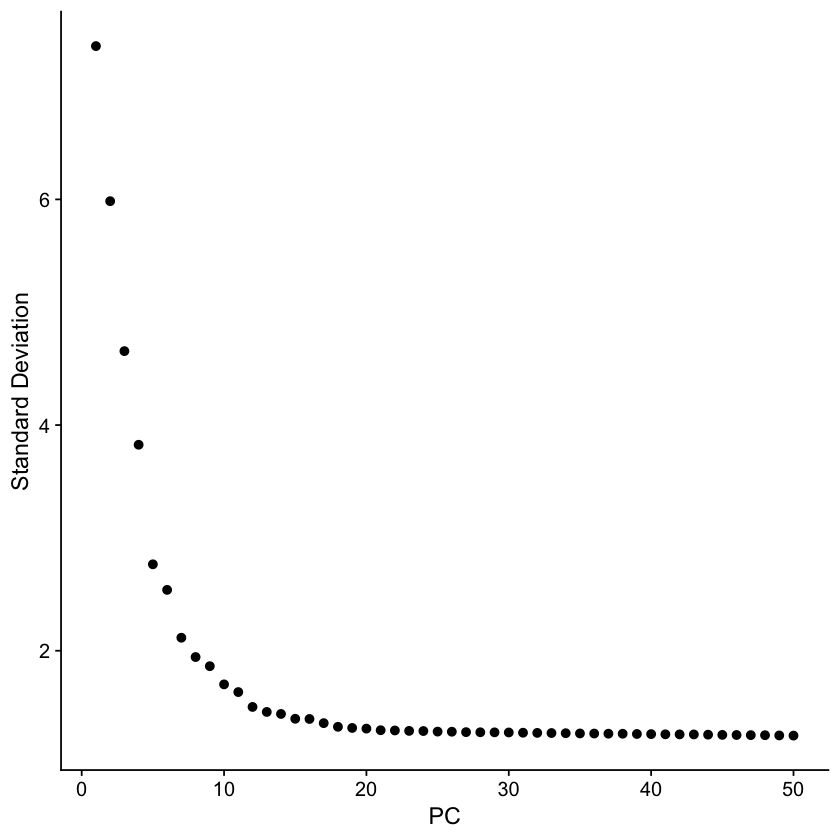

In [40]:
# Normalization & Feature Selection
print("Normalizing and Scaling...")

seurat_obj <- NormalizeData(seurat_obj, normalization.method = "LogNormalize", scale.factor = 10000)
seurat_obj <- FindVariableFeatures(seurat_obj, selection.method = "vst", nfeatures = 2000)
all.genes <- rownames(seurat_obj)
seurat_obj <- ScaleData(seurat_obj, features = all.genes)

# PCA
print("Running PCA...")

seurat_obj <- RunPCA(seurat_obj, features = VariableFeatures(object = seurat_obj))

# Elbow Plot
print(ElbowPlot(seurat_obj, ndims = 50))

In [40]:
# UMAP
dims_use <- 1:22 

print("Running UMAP...")
seurat_obj <- RunUMAP(seurat_obj, reduction.key = "UMAP_", dims = dims_use)

[1] "Running UMAP..."


17:31:09 UMAP embedding parameters a = 0.9922 b = 1.112

17:31:09 Read 11264 rows and found 22 numeric columns

17:31:09 Using Annoy for neighbor search, n_neighbors = 30

17:31:09 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

17:31:10 Writing NN index file to temp file /var/folders/lk/54m90rgj1fqg895lxsgx1l180000gn/T//Rtmp2GkPis/fileb3401153ddb9

17:31:10 Searching Annoy index using 10 threads, search_k = 3000

17:31:10 Annoy recall = 100%

17:31:10 Commencing smooth kNN distance calibration using 10 threads
 with target n_neighbors = 30

17:31:10 26 smooth knn distance failures

17:31:10 Initializing from normalized Laplacian + noise (using RSpectra)

17:31:11 Commencing optimization for 200 epochs, with 496198 positive edges

17:31:11 Using rng type: pcg

17:31:15

In [2]:
# seurat_obj <- readRDS("seurat_codeconv.rds")

[1] "Clustering..."


Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 11264
Number of edges: 430625

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9171
Number of communities: 11
Elapsed time: 1 seconds


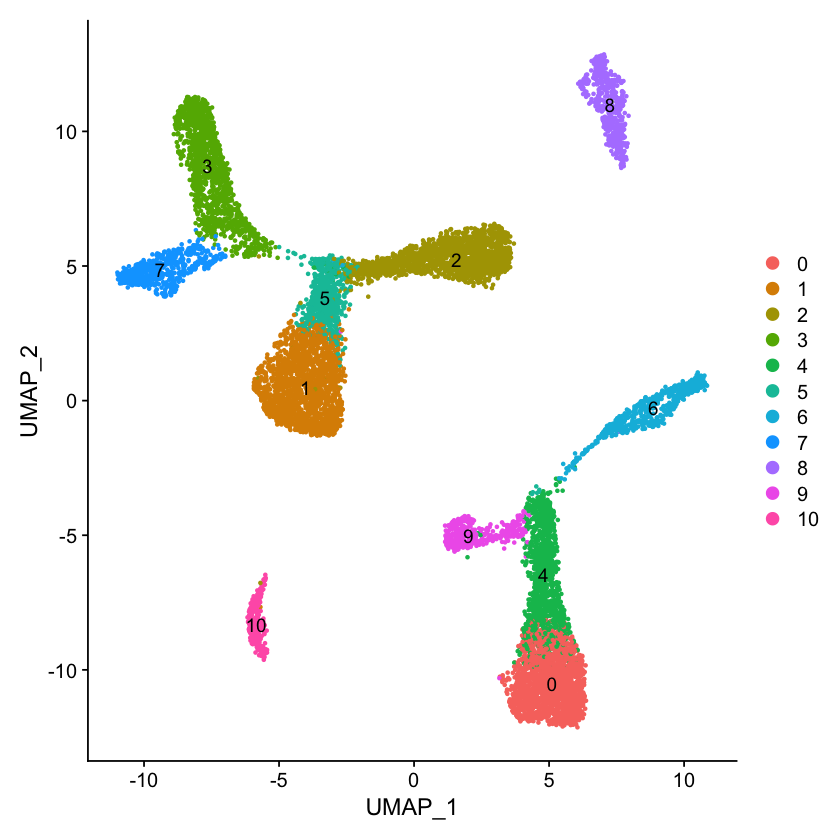

In [20]:
# In Silico Cell Clustering

print("Clustering...")
seurat_obj <- FindNeighbors(seurat_obj, dims = dims_use)
seurat_obj <- FindClusters(seurat_obj, resolution = 0.5) 
DimPlot(seurat_obj, reduction = "umap", label = TRUE, pt.size = 0.5)

In [54]:
all_markers <- FindAllMarkers(
  seurat_obj, 
  only.pos = TRUE,     
  min.pct = 0.25,        
  logfc.threshold = 0.5 
)

library(dplyr)
all_markers_sorted <- all_markers %>%
  group_by(cluster) %>%
  arrange(cluster, desc(avg_log2FC))

write.csv(all_markers_sorted, file = "all_cluster_markers.csv", row.names = FALSE)

print("Markers saved to 'all_cluster_markers.csv'")

top_markers <- all_markers_sorted %>%
    group_by(cluster) %>%
    slice_head(n = 3)

print(top_markers)

Calculating cluster Tumor Core

Calculating cluster Tumor Edge

Calculating cluster Tumor Front

Calculating cluster Suprabasal Keratinocytes

Calculating cluster Cornified Keratinocytes

Calculating cluster Skeletal Myocytes (Fast)

Calculating cluster Skeletal Myocytes (Slow)

Calculating cluster myCAFs

Calculating cluster iCAFs

Calculating cluster Fibroblasts

Calculating cluster Plasma Cells



[1] "Markers saved to 'all_cluster_markers.csv'"
# A tibble: 33 × 7
# Groups:   cluster [11]
       p_val avg_log2FC pct.1 pct.2 p_val_adj cluster                  gene  
       <dbl>      <dbl> <dbl> <dbl>     <dbl> <fct>                    <chr> 
 1 2.12e- 84       3.72 0.264 0.049 3.79e- 80 Tumor Core               CXCL11
 2 1.59e-146       3.36 0.46  0.092 2.85e-142 Tumor Core               UBE2C 
 3 4.26e-128       3.22 0.526 0.141 7.63e-124 Tumor Core               CXCL9 
 4 1.49e- 11       1.61 0.275 0.231 2.66e-  7 Tumor Edge               ITGB4 
 5 5.00e- 90       1.58 0.55  0.338 8.94e- 86 Tumor Edge               LAMC2 
 6 2.28e- 34       1.56 0.4   0.29  4.08e- 30 Tumor Edge               ITGA3 
 7 0               2.07 0.412 0.042 0         Tumor Front              HSPA2 
 8 0               2.07 0.286 0.029 0         Tumor Front              PTPRZ1
 9 0               1.93 0.719 0.117 0         Tumor Front              TP63  
10 1.75e-320       4.51 0.287 0.016 3.12e-316 Sup

In [21]:
new_cluster_ids <- c(
  # TUMOR COMPARTMENT
  "9" = "Tumor Core",             # UBE2C+, TOP2A+
  "4" = "Tumor Front",            # MMP1+, ITGB4+ 
  "0" = "Tumor Edge",             # TP63+, PTHLH+ 

  # EPITHELIAL CELLS
  "6" = "Suprabasal Keratinocytes", # DSG1+, KRT16+
  "8" = "Cornified Keratinocytes",  # LCE3E+, SPRR2A+
    
  # MUSCLE CELLS
  "3" = "Skeletal Myocytes (Fast)", # MYH2+, CKM+
  "7" = "Skeletal Myocytes (Slow)", # TNNI1+, TNNC1+

  # STROMA
  "2" = "myCAFs",                 # COL11A1+, POSTN+
  "1" = "Endothelial cells",      # PECAM1+
  "5" = "Fibroblasts",            # DCN+, SFRP2+
    
  # IMMUNE
  "10" = "Plasma Cells"           # IGLC1+, IGHG1+
)

# Apply to Seurat object
seurat_obj <- RenameIdents(seurat_obj, new_cluster_ids)
seurat_obj$CellType <- Idents(seurat_obj)

In [7]:
# seurat_obj <- readRDS("seurat_codeconv.rds")

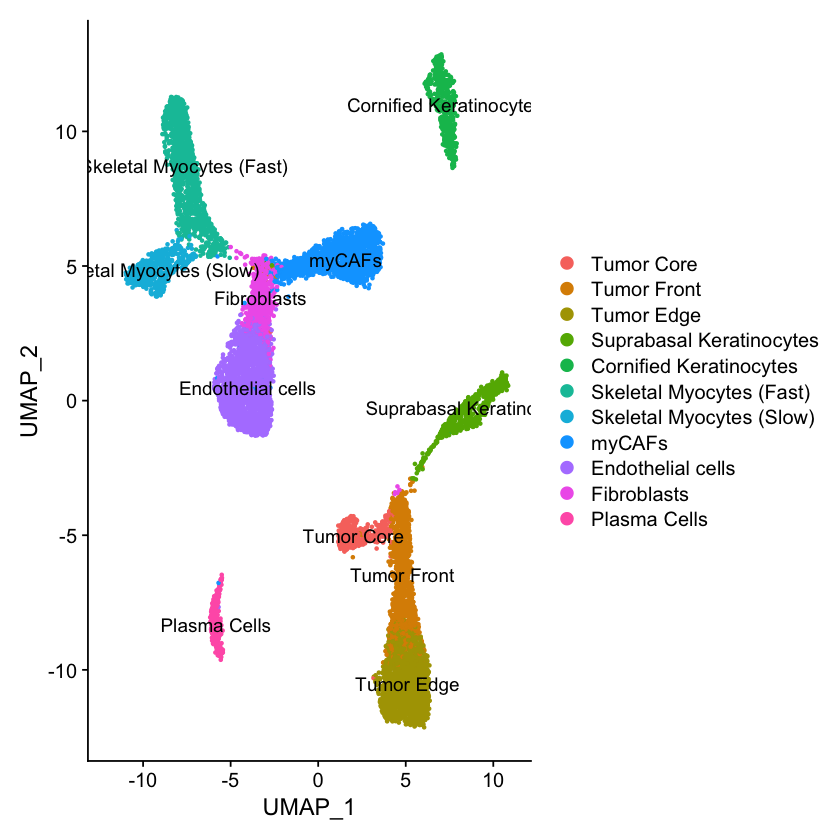

In [22]:
# UMAP Clusters 
DimPlot(seurat_obj, reduction = "umap", label = TRUE, pt.size = 0.5) + 
  xlim(-12, 11)

ggsave("CoDeconvClusters.jpeg", plot = last_plot(),
       width = 11, height = 10,     
       dpi = 600,                
       type = "cairo")

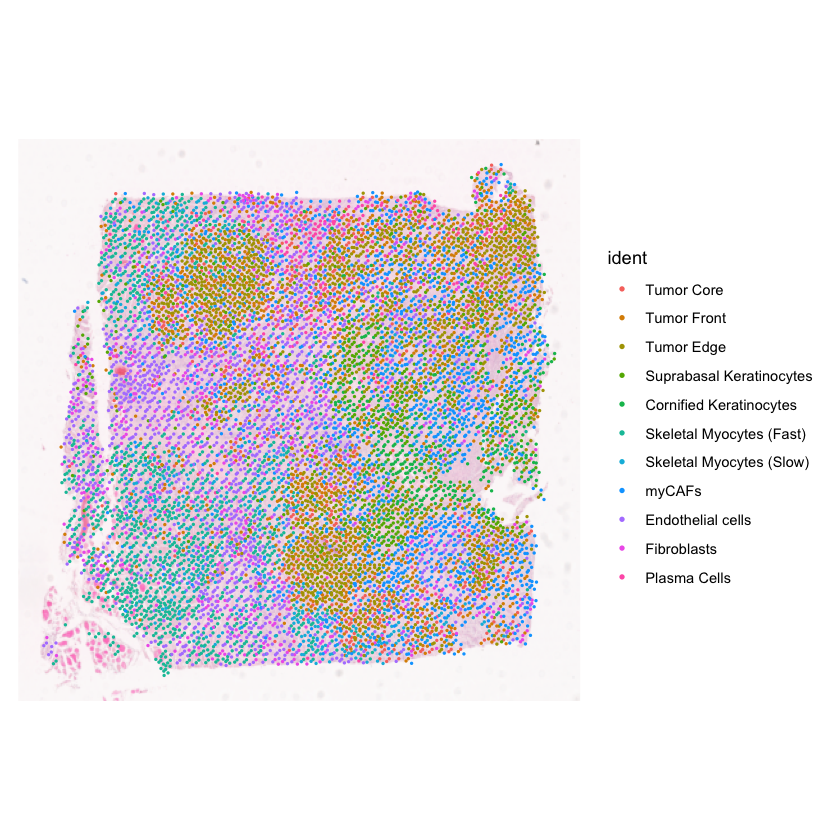

In [23]:
# Spatial Map of the Clusters
SpatialDimPlot(seurat_obj, label = FALSE, label.size = 3, pt.size.factor = 1.) + 
    guides(fill = guide_legend(override.aes = list(alpha = 1, stroke = 0)))

ggsave("CoDeconvSpatialClusters.jpeg", plot = last_plot(),
       width = 12, height = 10,     
       dpi = 600,                
       type = "cairo")

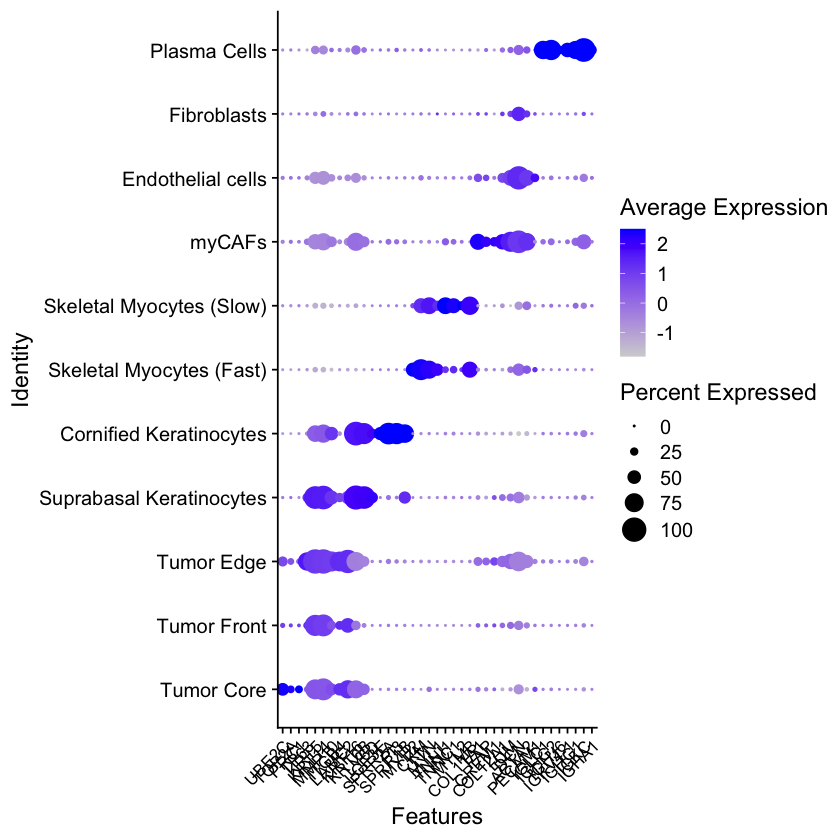

In [45]:
genes_to_plot <- c(
  "UBE2C", "TOP2A", "PRC1",
  "TP63", "KRT5", "KRT14",
  "MMP10", "ITGB4", "LAMC2",
  "KRT16", "KRT6B", "LY6D",
  "LCE3E", "SPRR2A", "PI3", "SPRR1B",
  "MYH2", "CKM", "TTN", "MYL1", 
  "TNNI1", "TNNC1", "MYL2", "MB", 
  "COL11A1", "FAP", "GREM1",
  "COL12A1","LUM", "DCN", "ACTA2","PECAM1", 
  "IGLC1","IGHG2","IGHJ6","IGKV4-1","IGHG1","IGKC","IGHA1"
    )

genes_to_plot <- unique(genes_to_plot)

# Remove any genes not found
genes_to_plot <- genes_to_plot[genes_to_plot %in% rownames(seurat_obj)]

DotPlot(
  seurat_obj,
  features = genes_to_plot,
) + 
  RotatedAxis() +                
  theme(axis.text.x = element_text(size = 10))

ggsave("CoDeconvDotPlot.jpeg", plot = last_plot(),
       width = 17, height = 5,     
       dpi = 600,                
       type = "cairo")

In [11]:
saveRDS(seurat_obj, "seurat_codeconv.rds")

### Intercellular Communication Analysis via CellChat

In [46]:
# Convert to dgCMatrix for CellChat

library(Matrix)
library(CellChat)

data.input <- GetAssayData(seurat_obj, assay = "Spatial", slot = "data")

data.input <- as(data.input, "dgCMatrix")
meta <- seurat_obj@meta.data

# Create CellChat Object 
CellChat <- createCellChat(object = data.input, 
                           meta = meta, 
                           group.by = "CellType")

[1] "Create a CellChat object from a data matrix"
Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  Tumor Core, Tumor Front, Tumor Edge, Suprabasal Keratinocytes, Cornified Keratinocytes, Skeletal Myocytes (Fast), Skeletal Myocytes (Slow), myCAFs, Endothelial cells, Fibroblasts, Plasma Cells 


In [81]:
CellChatDB <- CellChatDB.human

CellChatDB.use <- CellChatDB
CellChat@DB <- CellChatDB.use
CellChat <- subsetData(CellChat)
CellChat <- identifyOverExpressedGenes(CellChat)
CellChat <- identifyOverExpressedInteractions(CellChat)

# CellChat <- projectData(CellChat, PPI.human) # pre-V2 CellChat

CellChat <- computeCommunProb(CellChat)

CellChat <- computeCommunProbPathway(CellChat)

CellChat <- aggregateNet(CellChat)

library(NMF)
library(ggalluvial)

The number of highly variable ligand-receptor pairs used for signaling inference is 1956 
triMean is used for calculating the average gene expression per cell group. 
[1] ">>> Run CellChat on sc/snRNA-seq data <<< [2026-02-13 15:29:39.80489]"
[1] ">>> CellChat inference is done. Parameter values are stored in `object@options$parameter` <<< [2026-02-13 15:46:09.694154]"


In [82]:
CellChat@netP$pathways

[1] "COLLAGEN"  "FN1"       "LAMININ"   "THBS"      "APP"       "TENASCIN" 
 [7] "CD99"      "GAP"       "MIF"       "PERIOSTIN" "MK"        "ADGRG"    
[13] "CSPG4"     "PLAU"      "IGF"       "ANGPTL"    "DESMOSOME" "CXCL"     
[19] "CDH1"      "CDH"       "PECAM1"    "EPHA"      "SEMA3"

In [83]:
library(ComplexHeatmap)

ht <- netVisual_heatmap(CellChat, measure = "count")

jpeg("Dot_Plot_nComms.jpeg", width = 16.05, height = 15, units = "cm", res = 600)
draw(ht, heatmap_legend_side = "right",
         annotation_legend_side = "right")
dev.off()

Do heatmap based on a single object 




agg_record_324944051 
                   2

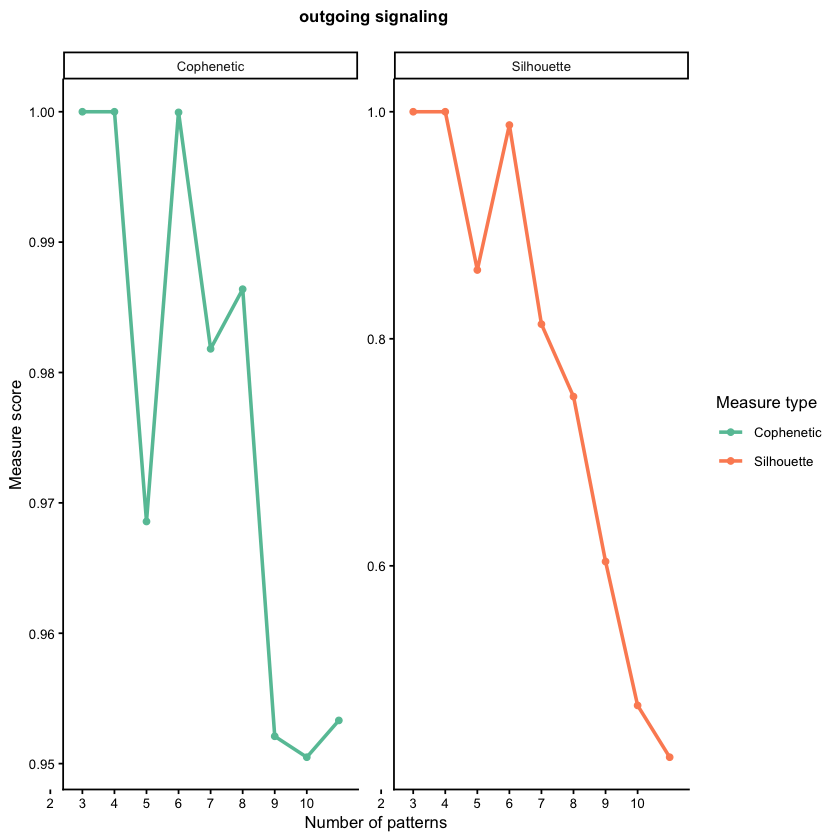

In [77]:
selectK(CellChat, pattern = "outgoing")

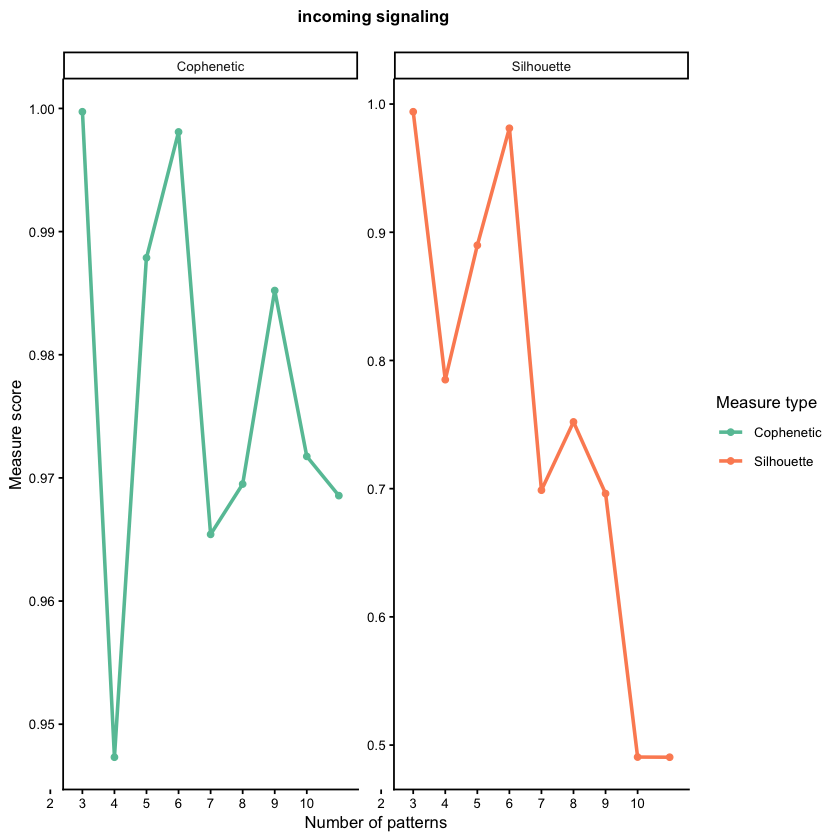

In [78]:
selectK(CellChat, pattern = "incoming")

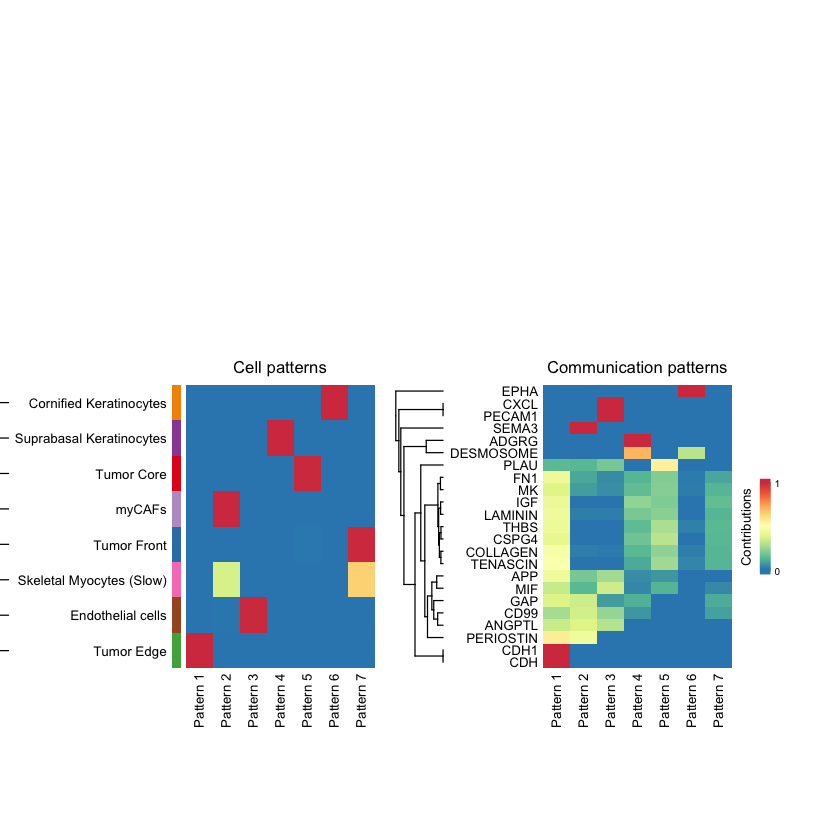

In [84]:
nPatterns = 10
CellChat <- identifyCommunicationPatterns(CellChat, 
                                          pattern = "outgoing", 
                                          k = nPatterns)
nPatterns = 7
CellChat <- identifyCommunicationPatterns(CellChat, 
                                          pattern = "incoming", 
                                          k = nPatterns)

In [85]:
# Dot plot of outgoing communications

p <- netAnalysis_dot(CellChat, pattern = "outgoing")

# p_flipped <- p & coord_flip()

ggsave(
  "Dot_Plot_Outgoing.jpeg",
  plot = p,
  # plot = p_flipped,
  device = "jpeg",
  width = 22,
  height = 10,
  units = "cm",
  dpi = 600,
  limitsize = TRUE
)

In [86]:
# Dot plot of incoming communications

p <- netAnalysis_dot(CellChat, pattern = "incoming")

# p_flipped <- p & coord_flip()

ggsave(
  "Dot_Plot_Incoming.jpeg",
  plot = p,
  # plot = p_flipped,
  device = "jpeg",
  width = 22,
  height = 8,
  units = "cm",
  dpi = 600,
  limitsize = TRUE
)

### Calculate co-localization matrix

Computing nearest neighbor graph

Computing SNN



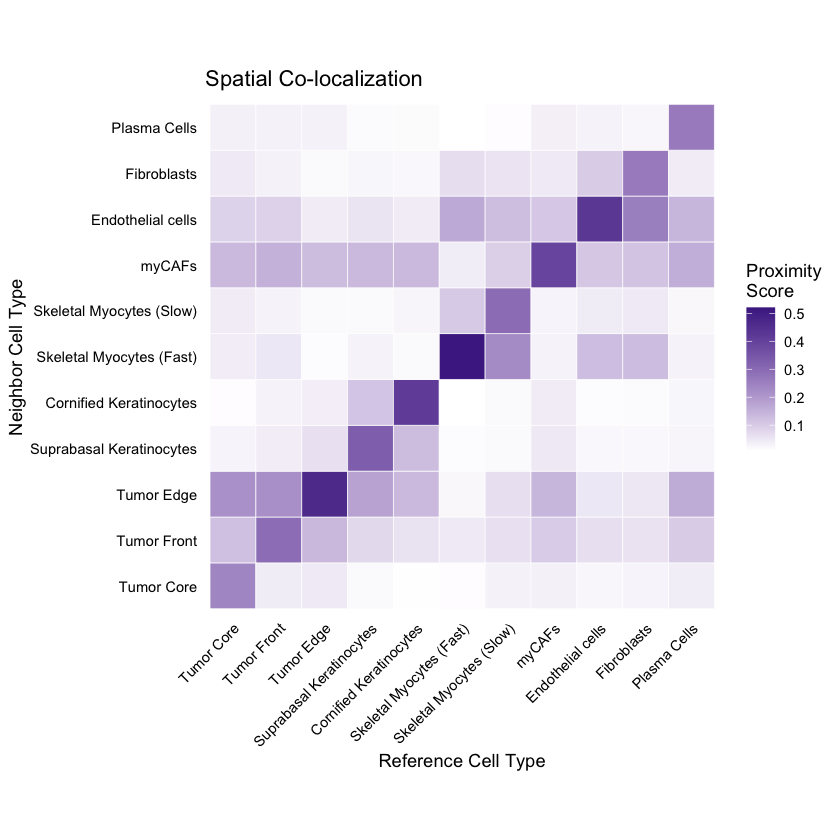

In [87]:
library(reshape2)

coords <- GetTissueCoordinates(seurat_obj)
neighbor_graph <- FindNeighbors(as.matrix(coords[, 1:2]), k.param = 6)$nn

Idents(seurat_obj) <- "CellType"
cell_types <- levels(seurat_obj)
type_matrix <- model.matrix(~ 0 + CellType, data = seurat_obj@meta.data)
colnames(type_matrix) <- cell_types

co_occurrence <- t(type_matrix) %*% neighbor_graph %*% type_matrix

co_occ_norm <- as.matrix(co_occurrence)
co_occ_norm <- sweep(co_occ_norm, 1, rowSums(co_occ_norm), FUN = "/")

p <- ggplot(melt(co_occ_norm), aes(Var1, Var2, fill = value)) +
  geom_tile(color = "white") +
  scale_fill_gradient(low = "white", high = "#4b2991", name = "Proximity\nScore") +
  coord_fixed() + 
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, color = "black"),
    axis.text.y = element_text(color = "black"),
    panel.grid = element_blank()
  ) +
  labs(title = "Spatial Co-localization", x = "Reference Cell Type", y = "Neighbor Cell Type")

ggsave("spatial_colocalization_heatmap.png", plot = p, dpi = 500, width = 8, height = 8)

# Display plot
print(p)